# Thesis

## 1. Data Exploration

### 1.1 Library Import

In [1]:
# Install all necessary libraries
import sys
print(sys.executable)

# Data exploration
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Cleaning
import string
import re
import nltk
import wordcloud
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from collections import Counter
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize

# Model Preparation
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.preprocessing import OneHotEncoder


# Legacy Models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU, SimpleRNN
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# BERT
from sklearn.model_selection import StratifiedKFold, train_test_split
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
import tensorflow as tf
print(tf.__version__)
from transformers import BertModel, AdamW, get_linear_schedule_with_warmup
from tqdm import tqdm
from joblib import dump
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader
from collections import deque

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


import warnings
warnings.filterwarnings("ignore")

/usr/bin/python3
2.17.0


### 1.2. Data Import

In [2]:
# Data Import
laptop = pd.read_csv('/content/Laptop_Train_v2.csv')
restaurants = pd.read_csv('/content/Restaurants_Train_v2.csv')

restaurants.head()



,id,Sentence,Aspect Term,polarity,from,to
0,3121,But the staff was so horrible to us.,staff,negative,8,13
1,2777,"To be completely fair, the only redeeming fact...",food,positive,57,61
2,1634,"The food is uniformly exceptional, with a very...",food,positive,4,8
3,1634,"The food is uniformly exceptional, with a very...",kitchen,positive,55,62
4,1634,"The food is uniformly exceptional, with a very...",menu,neutral,141,145


In [3]:
# Concatonate the two datasets

data = pd.concat([laptop, restaurants])
data.head()

,id,Sentence,Aspect Term,polarity,from,to
0,2339,I charge it at night and skip taking the cord ...,cord,neutral,41,45
1,2339,I charge it at night and skip taking the cord ...,battery life,positive,74,86
2,1316,The tech guy then said the service center does...,service center,negative,27,41
3,1316,The tech guy then said the service center does...,"""sales"" team",negative,109,121
4,1316,The tech guy then said the service center does...,tech guy,neutral,4,12


In [4]:
# Find number of unique IDs
unique_ids = data['id'].nunique()
print(f'Number of unique IDs: {unique_ids}')

print(len(data))

# Find number of ids which occur more than once (not including NaN)
duplicates = data.duplicated(subset='id',keep = False)
data = data[~duplicates]

print(len(data))


Number of unique IDs: 2687
6051
1039


### 1.3. Data Exploration

In [5]:
# Inspecting the data
print(data.shape)


(1039, 6)


Let us now try and visualise the data for potential anomalies, null values and other such issues. We will also try to understand the distribution of the data.

In [6]:
# Checking for missing values
data.isnull().sum()



,0
id,0
Sentence,0
Aspect Term,0
polarity,0
from,0
to,0


As we can see, there are no missing values in the data, let us now plot this in order to grasp its distribution.

Let us now understand how the target is distributed in the data.

polarity
positive    522
negative    323
neutral     159
conflict     35
Name: count, dtype: int64


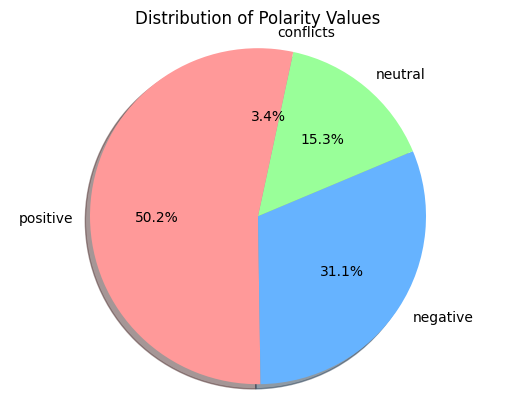

In [7]:
# Distribution of target values
target_counts = data.polarity.value_counts()
print(target_counts)

# Create a figure with a single subplot
fig, ax = plt.subplots()

# Colors and explode settings for better visualization
colors = ['#ff9999','#66b3ff', '#99ff99']

# Pie chart for target values
ax.pie(target_counts, labels=['positive', 'negative', 'neutral','conflicts'], colors=colors, autopct='%1.1f%%', startangle=90, shadow=True)
ax.set_title('Distribution of Polarity Values')
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Display the plot
plt.show()

In [8]:
# Drop "Conflict" Entries
data = data[data['polarity'] != 'conflict']

Now we will try to understand which kind of aspects are present in the data. All reviews are filtered by some specific identifying keyword, e.g. "computer" or "battery". Let us now try to understand the distribution of these aspects in the data.

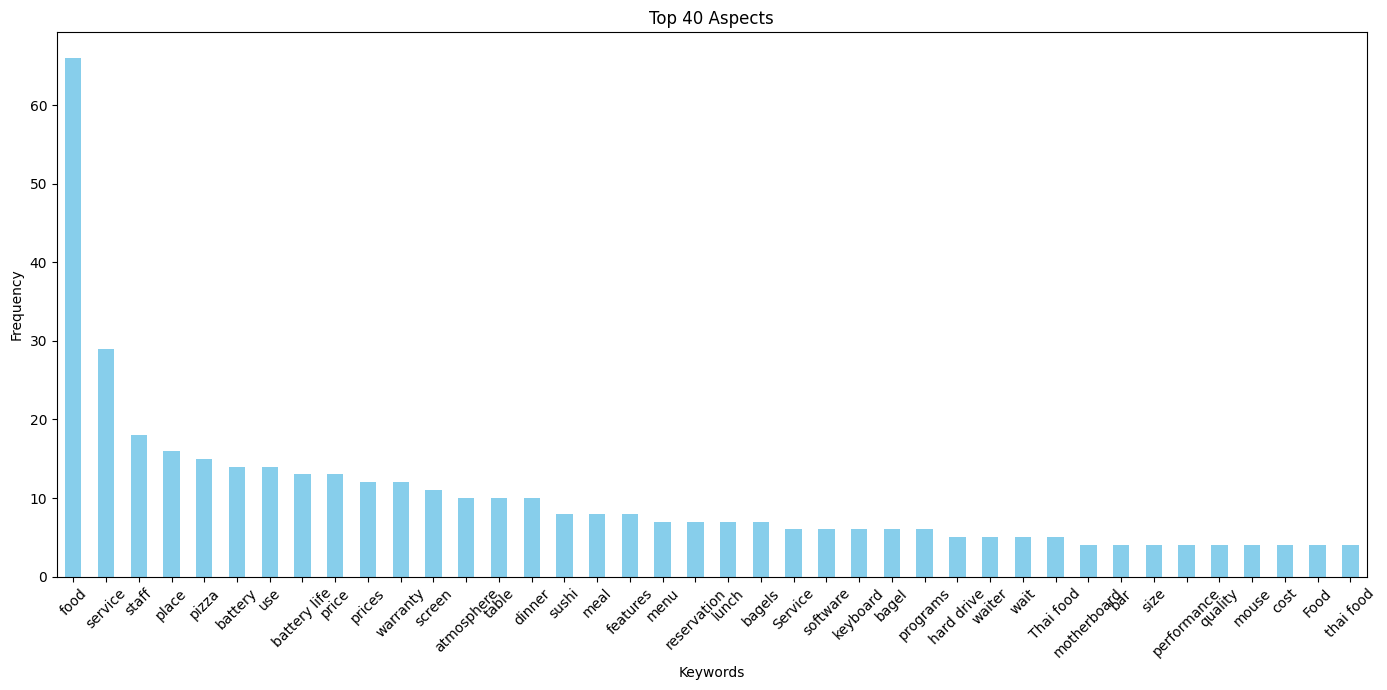

In [9]:
# Create a bar plot of the top 20 keywords
data['Aspect Term'].value_counts().head(40).plot(kind='bar', figsize=(14, 7), color='skyblue')
plt.title('Top 40 Aspects')
plt.xlabel('Keywords')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Now let us move on to the text itself

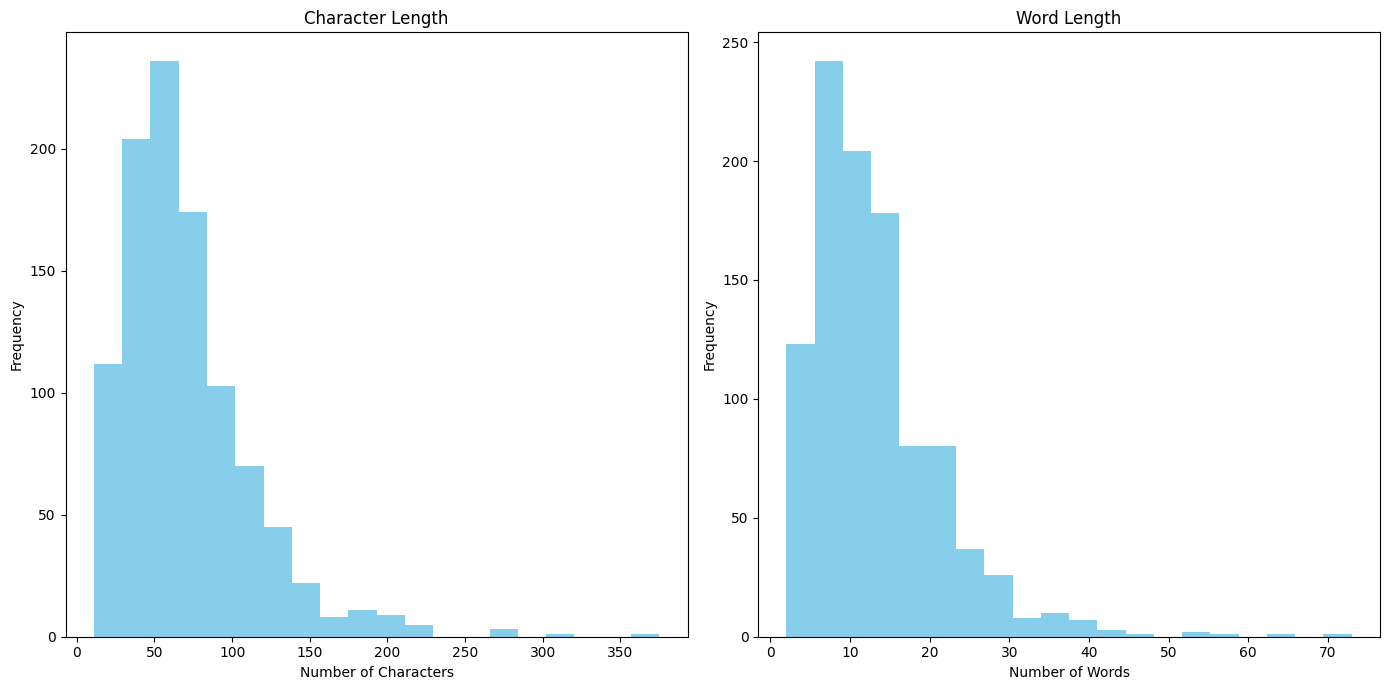

In [10]:
# Make two bar plots of the character and the word length of the tweets
# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Character length plot
data['Sentence'].str.len().plot(kind='hist', bins=20, color='skyblue', ax=ax[0])
ax[0].set_title('Character Length')
ax[0].set_xlabel('Number of Characters')
ax[0].set_ylabel('Frequency')

# Word length plot
data['Sentence'].str.split().map(lambda x: len(x)).plot(kind='hist', bins=20, color='skyblue', ax=ax[1])
ax[1].set_title('Word Length')
ax[1].set_xlabel('Number of Words')
ax[1].set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

Now it is helpful to understand whether these numbers differ between the two classes.

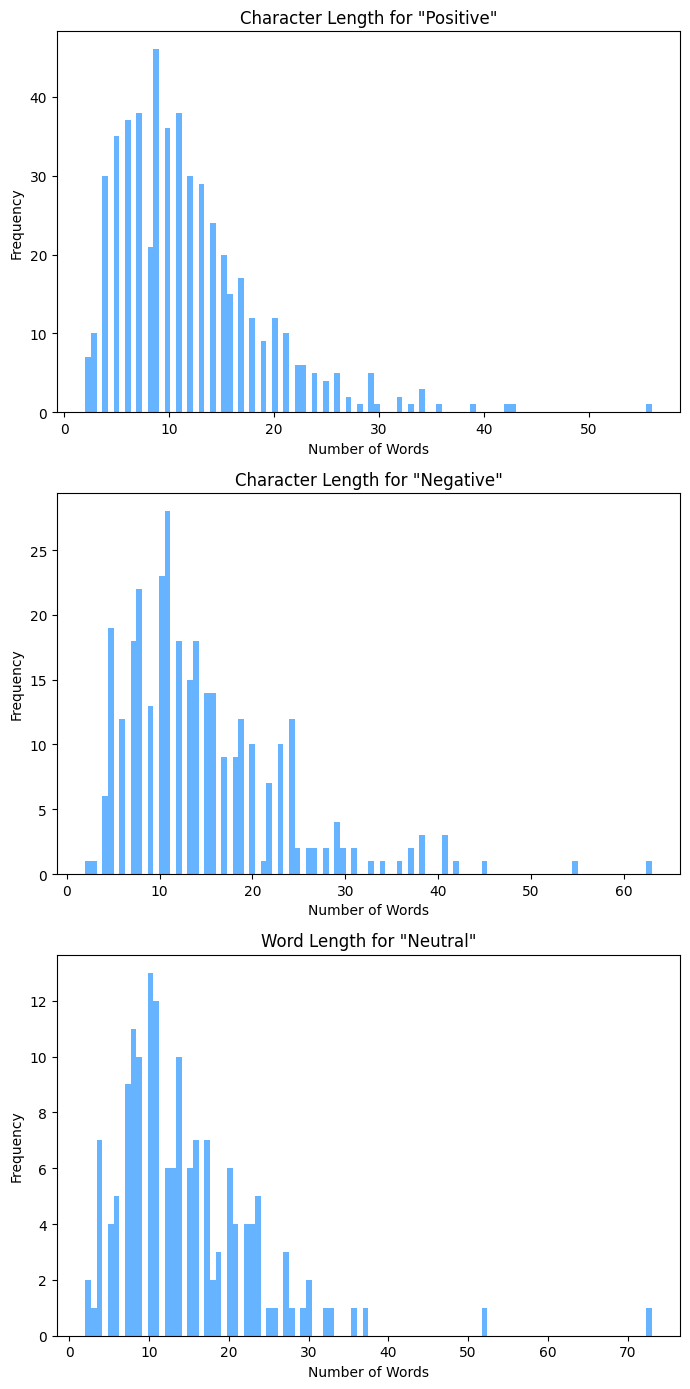

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(7, 14))

# Character length plot for disaster tweets
word_lengths_positive = data[data['polarity'] == "positive"]['Sentence'].str.split().map(len)
word_lengths_positive.plot(kind='hist', bins=100, color='#66b3ff', ax=ax[0])
ax[0].set_title('Character Length for "Positive"')
ax[0].set_xlabel('Number of Words')
ax[0].set_ylabel('Frequency')

# Character length plot for non-disaster tweets
word_lengths_negative = data[data['polarity'] == 'negative']['Sentence'].str.split().map(len)
word_lengths_negative.plot(kind='hist', bins=100, color='#66b3ff', ax=ax[1])
ax[1].set_title('Character Length for "Negative"')
ax[1].set_xlabel('Number of Words')
ax[1].set_ylabel('Frequency')

# Word length plot for disaster tweets
word_lengths_neutral = data[data['polarity'] == 'neutral']['Sentence'].str.split().map(len)
word_lengths_neutral.plot(kind='hist', bins=100, color='#66b3ff', ax=ax[2])
ax[2].set_title('Word Length for "Neutral"')
ax[2].set_xlabel('Number of Words')
ax[2].set_ylabel('Frequency')


# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


We see that the distributions do not vary significantly between the classes. All are quite evenly distributed. The exception is "Conflict" Terms of which there are not many in the data.

In [12]:
import random
from nltk.corpus import wordnet

# Download required resources for NLTK
nltk.download('wordnet')

# Define synonym replacement function
def synonym_replacement(sentence, n=1):
    words = sentence.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if wordnet.synsets(word)]))

    # If no synonyms found, return the original sentence
    if len(random_word_list) == 0:
        return sentence

    random.shuffle(random_word_list)
    num_replacements = min(n, len(random_word_list))

    for random_word in random_word_list[:num_replacements]:
        synonyms = wordnet.synsets(random_word)
        synonym = synonyms[0].lemmas()[0].name() if synonyms else random_word
        new_words = [synonym if word == random_word else word for word in new_words]

    return ' '.join(new_words)

# Define random deletion function
def random_deletion(sentence, p=0.2):
    words = sentence.split()

    if len(words) == 1:
        return sentence

    new_words = [word for word in words if random.uniform(0, 1) > p]

    if len(new_words) == 0:
        return random.choice(words)  # If all words are deleted, return one random word

    return ' '.join(new_words)

# Function to augment minority class data
def augment_minority_class(data, label, target_count, n_synonym=1, p_deletion=0.2):
    augmented_sentences = []
    sentences = data[data['polarity'] == label]['Sentence'].values
    current_count = len(sentences)

    while current_count < target_count:
        sentence = random.choice(sentences)

        # Apply synonym replacement and random deletion
        if random.uniform(0, 1) < 0.5:
            augmented_sentence = synonym_replacement(sentence, n=n_synonym)
        else:
            augmented_sentence = random_deletion(sentence, p=p_deletion)

        augmented_sentences.append((augmented_sentence, label))
        current_count += 1

    return pd.DataFrame(augmented_sentences, columns=['Sentence', 'polarity'])

# Count original values
original_counts = data['polarity'].value_counts()

# Target count (balance to match the highest class "positive" = 3151)
target_count = original_counts['positive']

# Augment "negative" and "neutral" classes
augmented_negative = augment_minority_class(data, label='negative', target_count=target_count)
augmented_neutral = augment_minority_class(data, label='neutral', target_count=target_count)

# Combine original data with augmented data
data = pd.concat([data, augmented_negative, augmented_neutral], ignore_index=True)

# Shuffle the data to ensure the new data is mixed well
data = data.sample(frac=1).reset_index(drop=True)

# Check new class distribution
print(data['polarity'].value_counts())


[nltk_data] Downloading package wordnet to /root/nltk_data...


polarity
neutral     522
positive    522
negative    522
Name: count, dtype: int64


### 1.4 Data Cleaning

Let us first fill all empty values:

Since these are reviews, they contain a lot of noise. We will now clean the data by removing all special characters, numbers and other such noise.

Lets begin by removing punctuation and special characters.

In [13]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [14]:
# Creating a function to remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply the function to the text column
data['clean_sentence'] = data['Sentence'].apply(remove_punctuation)

Moving on to removing URLs

In [15]:
# Removing URLs
def remove_URL(text):
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'',text)

data["clean_sentence"] = data["clean_sentence"].apply(remove_URL)

In [16]:
# Removing HTML tags
def remove_html(text):
    clean = re.compile('<.*?>')
    # Use sub() to replace HTML tags with an empty string
    return re.sub(clean, '', text)

data["clean_sentence"] = data["clean_sentence"].apply(remove_html)

In [17]:
data["clean_sentence"] = data["clean_sentence"].str.lower()

Let us further analyse the data by removing stopwords. Before we do this, let us understand how stopwords are distributed in the data.

In [18]:
# Removing stopwords
nltk.download('stopwords')
stop = set(stopwords.words('english'))

def remove_stopwords(text):
    text = [word for word in text.split() if word.lower() not in stop]
    return " ".join(text)

data["clean_sentence"] = data["clean_sentence"].apply(remove_stopwords)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


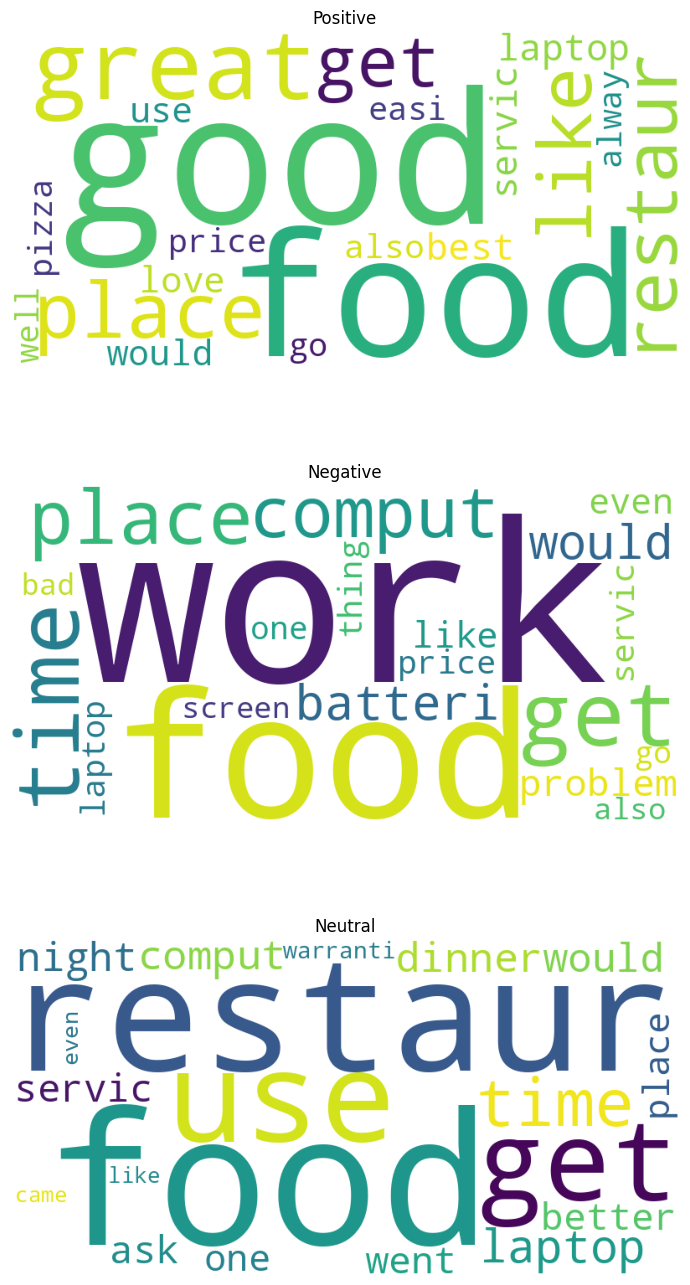

In [20]:

fig, ax = plt.subplots(3, 1, figsize=(7, 14))

# Get the most common words in positive sentences
positive_words = data[data['polarity'] == "positive"]['clean_sentence'].str.split().explode()
positive_common_words = Counter(positive_words).most_common(20)

# Get the most common words in negative sentences
negative_words = data[data['polarity'] == "negative"]['clean_sentence'].str.split().explode()
negative_common_words = Counter(negative_words).most_common(20)

# Get the most common words in neutral sentences
neutral_words = data[data['polarity'] == "neutral"]['clean_sentence'].str.split().explode()
neutral_common_words = Counter(neutral_words).most_common(20)

# Positive word cloud
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate_from_frequencies(dict(positive_common_words))
ax[0].imshow(wordcloud)
ax[0].set_title('Positive')
ax[0].axis('off')

# Negative word cloud
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate_from_frequencies(dict(negative_common_words))
ax[1].imshow(wordcloud)
ax[1].set_title('Negative')
ax[1].axis('off')

# Neutral word cloud
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate_from_frequencies(dict(neutral_common_words))
ax[2].imshow(wordcloud)
ax[2].set_title('Neutral')
ax[2].axis('off')
# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


There are still unnecessary words such as like "amp" and "gt" in the data. Let us remove these as well.

In [21]:
# Removing common words

# Create a list of common words
common_words = ['amp', 'like', 'get', 'one', 'new', 'via', 'would', 'video', 'know', 'us', 'back', 'watch', 'good', '2', 'first', 'last', 'going',   'still',
                'see', 'think', 'made', 'even', 'look', 'many', 'may', 'next',
                'great', 'well', 'take', 'year', 'say', 'want', 'best', 'come', 'big', 'use', 'week', 'ever', 'let', 'show', 'find',"got",'im']

# Function to find common words in the text
def remove_common(text):
    text = [word for word in text.split() if word not in common_words]
    return " ".join(text)

# Apply the function to the text column
data['clean_sentence'] = data['clean_sentence'].apply(remove_common)

## 2. Model Selection and Training

We will initially run sentiment analysis using all legacy models discussed in the thesis on the pure sentences (not including the aspect term). This however only works if there is only one aspect per sentence. So let us first filter out all sentences that contain more than one aspect.

### Preprocessing

In [27]:

# Preprocessing data
polarity_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
data['numerical_polarity'] = data['polarity'].map(polarity_mapping)


# Flatten all token lists to create a vocabulary
all_tokens = [token for sublist in data['tokenized_text'].dropna() for token in sublist]
unique_tokens = np.unique(all_tokens)

# Create a dictionary to map tokens to indices
token_index = {token: idx + 1 for idx, token in enumerate(unique_tokens)}  # +1 to reserve 0 for padding/unknown

# Convert tokenized_text to indices
def tokens_to_indices(tokens):
    return [token_index.get(token, 0) for token in tokens]  # 0 is used for unknown tokens

data['tokenized_indices'] = data['tokenized_text'].apply(tokens_to_indices)

# Prepare your data
X = pad_sequences(data['tokenized_indices'].dropna().values, maxlen=100)  # Pad sequences
y = data['numerical_polarity'].dropna().values  # Your target variable
y = to_categorical(y, num_classes=3)

In [28]:
def legacy(model_type):
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_no = 1
    max_accuracies_per_fold = []

    for train, test in kfold.split(X, np.argmax(y, axis=1)):
        model = Sequential([
            Embedding(input_dim=len(token_index) + 1, output_dim=64, input_length=100),
            model_type(64),
            Dropout(0.5),
            Dense(3, activation='softmax')
        ])

        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, verbose=1, restore_best_weights=True)

        print(f'Training for fold {fold_no} ...')
        history = model.fit(X[train], y[train],
                            epochs=10,
                            batch_size=32,
                            validation_data=(X[test], y[test]),
                            callbacks=[early_stopping])

        if 'val_accuracy' in history.history:
            max_accuracy = max(history.history['val_accuracy'])
            max_accuracies_per_fold.append(max_accuracy)

        print(f'Best accuracy for fold {fold_no}: {max_accuracy}')

        fold_no += 1

    mean_max_accuracy = np.mean(max_accuracies_per_fold)
    print(f"Mean of maximum validation accuracies across all folds is: {mean_max_accuracy:.4f}")





### 2.1 RNN

In [29]:
legacy(SimpleRNN)

Training for fold 1 ...
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.3606 - loss: 1.1072 - val_accuracy: 0.5096 - val_loss: 1.0498
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6588 - loss: 0.9689 - val_accuracy: 0.6051 - val_loss: 0.9563
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8334 - loss: 0.7291 - val_accuracy: 0.6497 - val_loss: 0.8230
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9191 - loss: 0.4273 - val_accuracy: 0.5796 - val_loss: 0.9040
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9355 - loss: 0.2539 - val_accuracy: 0.6911 - val_loss: 0.7134
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9791 - loss: 0.1561 - val_accuracy: 0.6879 - val_loss: 0.7135
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9895 - loss: 0.0997 - val_accuracy: 0.6975 - val_loss: 0.7285
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9949 - loss: 0.0709 - 

### 2.2 LSTM

In [30]:
legacy(LSTM)

Training for fold 1 ...
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3394 - loss: 1.0967 - val_accuracy: 0.4809 - val_loss: 1.0843
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5846 - loss: 1.0654 - val_accuracy: 0.5064 - val_loss: 1.0154
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6883 - loss: 0.8810 - val_accuracy: 0.7452 - val_loss: 0.7194
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8607 - loss: 0.5030 - val_accuracy: 0.7420 - val_loss: 0.5893
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9181 - loss: 0.2412 - val_accuracy: 0.7834 - val_loss: 0.5413
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9575 - loss: 0.1411 - val_accuracy: 0.7803 - val_loss: 0.6449
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9713 - loss: 0.0900 - val_accuracy: 0.7675 - val_loss: 0.8555
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9739 - loss: 0.0778 - val_acc

### 2.3. GRU

In [31]:
legacy(GRU)

Training for fold 1 ...
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3377 - loss: 1.0960 - val_accuracy: 0.5892 - val_loss: 1.0698
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6668 - loss: 1.0211 - val_accuracy: 0.6656 - val_loss: 0.8638
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7873 - loss: 0.6861 - val_accuracy: 0.7325 - val_loss: 0.6130
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8960 - loss: 0.3364 - val_accuracy: 0.7548 - val_loss: 0.6141
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9285 - loss: 0.2028 - val_accuracy: 0.8121 - val_loss: 0.4893
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9730 - loss: 0.0901 - val_accuracy: 0.8121 - val_loss: 0.5008
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9885 - loss: 0.0550 - val_accuracy: 0.7962 - val_loss: 0.5732
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9926 - loss: 0.0335 - val_acc

### 2.2 Sentiment Analysis using BERT

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertTokenizer, BertModel
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data import Dataset, DataLoader, Subset

df = pd.DataFrame(data)

# Preprocess text using BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
max_length = 64
encoded = tokenizer(df['Sentence'].tolist(), padding=True, truncation=True, max_length=max_length, return_tensors='pt')

# Aspect preprocessing (use OneHotEncoder for aspect encoding)
aspect_tokenizer = OneHotEncoder(sparse_output=False)
aspect_encoded = aspect_tokenizer.fit_transform(df[['Aspect Term']].values)

# Label encoding
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
labels = df['polarity'].map(label_mapping).values
labels = torch.tensor(labels)




tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [33]:
from torch.utils.data import DataLoader, Subset, Dataset
from transformers import BertModel
import torch.nn as nn
import torch.optim as optim
import torch
from sklearn.model_selection import train_test_split

# Assuming 'encoded' and 'labels' are your preprocessed data and labels
class SentimentDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx]
        }

# Split data into training and validation indices
train_idx, val_idx = train_test_split(range(len(labels)), test_size=0.2, random_state=42)

# Create training and validation datasets
train_dataset = Subset(SentimentDataset(encoded['input_ids'], encoded['attention_mask'], labels), train_idx)
val_dataset = Subset(SentimentDataset(encoded['input_ids'], encoded['attention_mask'], labels), val_idx)

# Create dataloaders for training and validation
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# Define the model using BERT
class SentimentClassifier(nn.Module):
    def __init__(self, bert_model_name, num_labels):
        super(SentimentClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.classifier = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, 64),  # Correct dimension
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, num_labels),
            nn.Softmax(dim=1)
        )

    def forward(self, input_ids, attention_mask):
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sentence_embedding = bert_outputs.pooler_output
        return self.classifier(sentence_embedding)

# Initialize the model, optimizer, and loss function
model = SentimentClassifier(bert_model_name='bert-base-uncased', num_labels=3)
optimizer = optim.Adam(model.parameters(), lr=3e-5)
criterion = nn.CrossEntropyLoss()

# Train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

SentimentClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, eleme

Epoch 1/10: 100%|██████████| 157/157 [00:07<00:00, 22.08it/s, accuracy=0.601, loss=0.985]


Epoch 1/10, Loss: 0.9849, Accuracy: 0.6006


Epoch 1/10 [Validation]: 100%|██████████| 40/40 [00:00<00:00, 98.84it/s]


Validation - Epoch 1/10, Loss: 0.8986, Accuracy: 0.6720


Epoch 2/10: 100%|██████████| 157/157 [00:05<00:00, 28.63it/s, accuracy=0.769, loss=0.798]


...

Validation - Epoch 9/10, Loss: 0.9608, Accuracy: 0.5892


Epoch 10/10: 100%|██████████| 157/157 [00:05<00:00, 28.99it/s, accuracy=0.787, loss=0.763]


Epoch 10/10, Loss: 0.7625, Accuracy: 0.7867


Epoch 10/10 [Validation]: 100%|██████████| 40/40 [00:00<00:00, 113.37it/s]


Validation - Epoch 10/10, Loss: 0.8016, Accuracy: 0.7580
Best validation accuracy: 0.7898


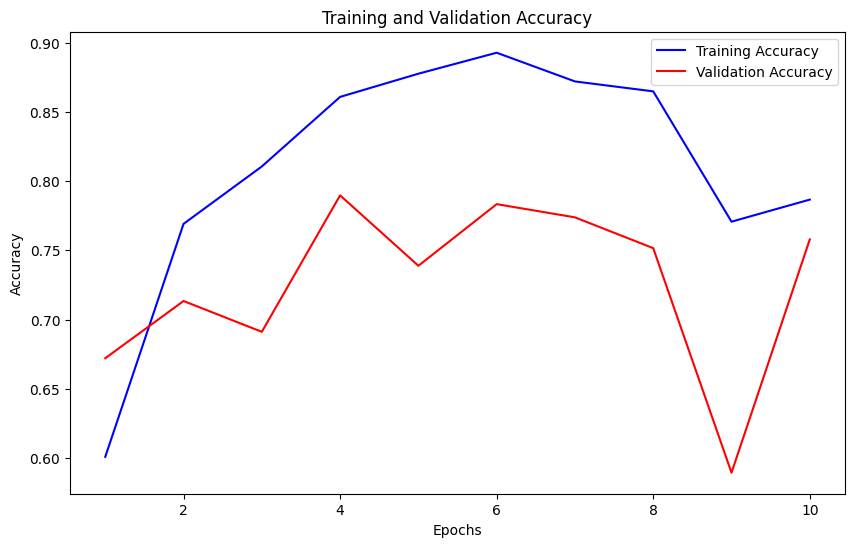

In [34]:
from tqdm import tqdm
import matplotlib.pyplot as plt

def train_model(model, train_dataloader, val_dataloader, optimizer, criterion, num_epochs=10):
    model.train()  # Set model to training mode

    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        total_loss = 0
        correct = 0
        total = 0
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Calculate accuracy
            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Update Progress
            progress_bar.set_postfix(loss=total_loss / len(train_dataloader), accuracy=correct / total)

        avg_loss = total_loss / len(train_dataloader)
        accuracy = correct / total
        train_accuracies.append(accuracy)
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

        # Validation loop
        model.eval()  # Set model to evaluation mode
        val_loss = 0
        val_correct = 0
        val_total = 0
        val_progress_bar = tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]")

        with torch.no_grad():
            for batch in val_progress_bar:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                # Forward pass
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # Calculate accuracy
                _, preds = torch.max(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        avg_val_loss = val_loss / len(val_dataloader)
        val_accuracy = val_correct / val_total
        val_accuracies.append(val_accuracy)
        print(f"Validation - Epoch {epoch + 1}/{num_epochs}, Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.4f}")

    best_val_accuracy = max(val_accuracies)
    print(f"Best validation accuracy: {best_val_accuracy:.4f}")

    # Plotting training accuracy and loss
    epochs_range = range(1, num_epochs + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, train_accuracies, label='Training Accuracy', color='blue')
    plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='red')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Train the model
train_model(model, train_dataloader, val_dataloader, optimizer, criterion, num_epochs=10)
